In [ ]:
from google.colab import files
uploaded = files.upload()


Saving train.csv to train (1).csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv("train.csv", encoding='latin1')

# Display first 5 rows
df.head()

,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797,27400.0,105
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044,2381740.0,18
3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265,470.0,164
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,noon,60-70,Angola,32866272,1246700.0,26


In [ ]:
# Dataset info
print("Dataset Info:")
df.info()

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Dataset shape
print("\nShape:", df.shape)


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   textID            27481 non-null  object 
 1   text              27480 non-null  object 
 2   selected_text     27480 non-null  object 
 3   sentiment         27481 non-null  object 
 4   Time of Tweet     27481 non-null  object 
 5   Age of User       27481 non-null  object 
 6   Country           27481 non-null  object 
 7   Population -2020  27481 non-null  int64  
 8   Land Area (Km²)   27481 non-null  float64
 9   Density (P/Km²)   27481 non-null  int64  
dtypes: float64(1), int64(2), object(7)
memory usage: 2.1+ MB

Missing Values:
textID              0
text                1
selected_text       1
sentiment           0
Time of Tweet       0
Age of User         0
Country             0
Population -2020    0
Land Area (Km²)     0
Density (P/Km²)     0
dtype: int64



sentiment
neutral     11118
positive     8582
negative     7781
Name: count, dtype: int64


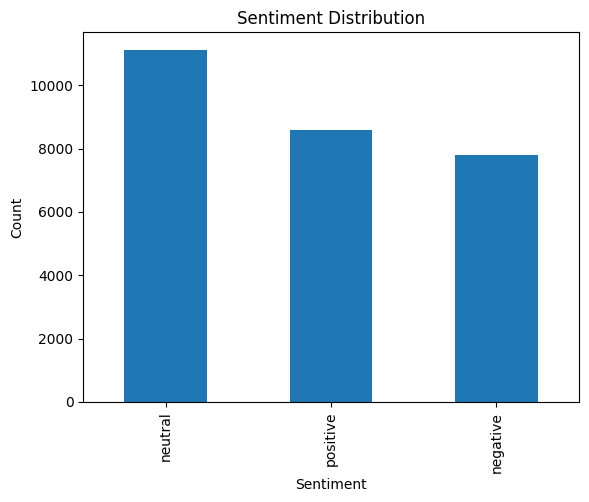

In [ ]:
# Count sentiment values
sentiment_count = df['sentiment'].value_counts()

print(sentiment_count)

# Plot sentiment distribution
sentiment_count.plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()


sentiment    negative  neutral  positive
Age of User                             
0-20             1290     1898      1393
21-30            1336     1830      1414
31-45            1315     1814      1451
46-60            1271     1865      1444
60-70            1266     1845      1469
70-100           1303     1866      1411


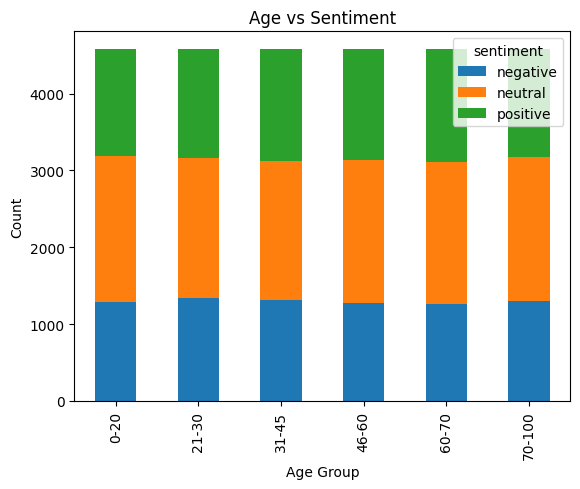

In [ ]:
age_sentiment = pd.crosstab(df['Age of User'], df['sentiment'])

print(age_sentiment)

age_sentiment.plot(kind='bar', stacked=True)
plt.title("Age vs Sentiment")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.show()


In [ ]:
country_sentiment = pd.crosstab(df['Country'], df['sentiment'])

print(country_sentiment.head())


sentiment    negative  neutral  positive
Country                                 
Afghanistan        40       66        43
Albania            47       59        43
Algeria            51       55        43
Andorra            47       54        48
Angola             48       54        47


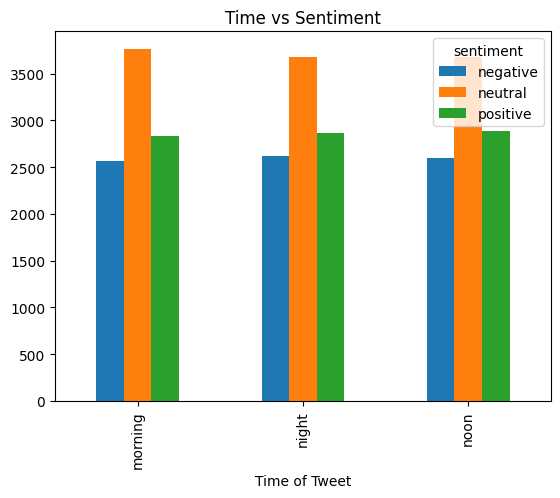

In [ ]:
time_sentiment = pd.crosstab(df['Time of Tweet'], df['sentiment'])

time_sentiment.plot(kind='bar')
plt.title("Time vs Sentiment")
plt.show()

In [ ]:
df.to_csv("processed_dataset.csv", index=False)


In [ ]:
df['sentiment_numeric'] = df['sentiment'].map({
    'negative': -1,
    'neutral': 0,
    'positive': 1
})

df.head()


,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²),sentiment_numeric
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60,0
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797,27400.0,105,-1
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044,2381740.0,18,-1
3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265,470.0,164,-1
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,noon,60-70,Angola,32866272,1246700.0,26,-1
